In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel("D:\PLI_Export_Project\data\india_exports_commodities.xlsx")

# Set commodity as index
df.set_index("Commodity", inplace=True)

df.head()


,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
Commodity,,,,,,
Tea,5851,5604,5597,6582,6843,7818
Coffee,5237,5340,7614,9191,10645,15292
Rice,45427,65405,72116,89622,86194,105719
Other cereals,1455,5198,8109,9615,4274,2297
Tobacco,6409,6497,6882,9740,12006,16728


In [24]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)


In [25]:
total_exports = df.sum()
print(total_exports)


2019-20    2219854
2020-21    2159044
2021-22    3147021
2022-23    3621550
2023-24    3618954
2024-25    3701070
dtype: int64


In [26]:
pli_sectors = [
    "Electronic Goods",
    "Drugs & Pharmaceuticals",
    "Engineering Goods",
    "Organic & Inorganic Chemicals",
    "Plastic & Linoleum"
]

pli_df = df.loc[pli_sectors]
pli_df


,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
Commodity,,,,,,
Electronic Goods,82936,81949,116896,189952,241171,327173
Drugs & Pharmaceuticals,146751,181261,183340,204101,230627,257989
Engineering Goods,557603,567800,836128,859266,904936,986676
Organic & Inorganic Chemicals,156441,163726,218907,243541,243284,242792
Plastic & Linoleum,53462,55374,73195,67070,66999,75436


In [27]:
def cagr(start, end, years):
    return ((end / start) ** (1/years) - 1) * 100

years = 5

cagr_results = {}

for sector in pli_df.index:
    cagr_results[sector] = round(
        cagr(pli_df.loc[sector].iloc[0],
             pli_df.loc[sector].iloc[-1],
             years), 2)

cagr_df = pd.DataFrame.from_dict(
    cagr_results, orient="index", columns=["CAGR (%)"]
)


cagr_df.to_excel(r"D:\PLI_Export_Project\figures\cagr_results.xlsx")
cagr_df

PermissionError: [Errno 13] Permission denied: 'D:\\PLI_Export_Project\\figures\\cagr_results.xlsx'

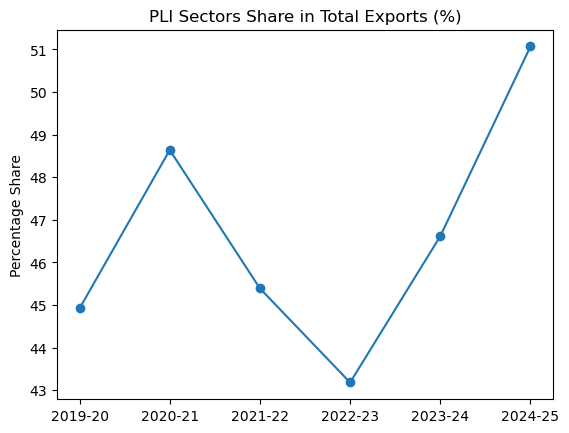

In [36]:
export_shares = df.divide(total_exports, axis=1) * 100

pli_share = export_shares.loc[pli_sectors].sum()

pli_share.plot(marker='o')
plt.title("PLI Sectors Share in Total Exports (%)")
plt.ylabel("Percentage Share")
plt.savefig("D:\PLI_Export_Project/figures/pli_share_trend.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
def hhi(column):
    shares = column / column.sum()
    return (shares ** 2).sum()

hhi_index = df.apply(hhi)

plt.plot(hhi_index, marker='o')
plt.title("Export Concentration Index (HHI)")
plt.savefig(r"D:\PLI_Export_Project\figures\hhi_index.png", dpi=300)
plt.show()


In [ ]:
pli_df.T.plot(figsize=(10,6))
plt.title("Export Trends of PLI Sectors")
plt.ylabel("₹ Crore")
plt.savefig(r"D:\PLI_Export_Project\figures\pli_sector_growth.png", dpi=300)
plt.show()


In [ ]:
cagr_df.sort_values(by="CAGR (%)", ascending=False)


In [ ]:
export_shares.to_excel(r"D:\PLI_Export_Project\figures\export_shares.xlsx")

pli_share


In [ ]:
df.loc["Petroleum Products"]


In [ ]:
df_no_petroleum = df.drop("Petroleum Products")

total_no_petroleum = df_no_petroleum.sum()

export_shares_no_petroleum = df_no_petroleum.divide(total_no_petroleum, axis=1) * 100

pli_share_no_petroleum = export_shares_no_petroleum.loc[pli_sectors].sum()

pli_share_no_petroleum


In [ ]:
plt.figure(figsize=(8,5))
pli_share_no_petroleum.plot(marker='o')
plt.title("PLI Share (Excluding Petroleum)")
plt.ylabel("Percentage Share")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig(r"D:\PLI_Export_Project\figures\pli_share_no_petroleum.png", dpi=300)
plt.show()


In [ ]:
plt.savefig(r"D:\PLI_Export_Project\figures\pli_share_no_petroleum.png", dpi=300)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
file_path = r"D:\PLI_Export_Project\data\india_exports_commodities.xlsx"

df = pd.read_excel(file_path)

df.set_index("Commodity", inplace=True)

df = df.apply(pd.to_numeric, errors='coerce')
pli_sectors = [
    "Engineering Goods",
    "Electronic Goods",
    "Drugs & Pharmaceuticals",
    "Organic & Inorganic Chemicals",
    "Plastic & Linoleum",
    "Man-made Yarn/Fabs./made-ups etc."
]

pli_df = df.loc[pli_sectors]


PRE-PLI VS POST-PLI

In [ ]:
print(pli_df.columns)


In [ ]:
pre_growth = ((pli_df["2020-21"] - pli_df["2019-20"]) / pli_df["2019-20"]) * 100

post_growth = ((pli_df["2024-25"] - pli_df["2021-22"]) / pli_df["2021-22"]) * 100

growth_compare = pd.DataFrame({
    "Pre_PLI_Growth_%": pre_growth,
    "Post_PLI_Growth_%": post_growth
})

growth_compare["Growth_Acceleration"] = (
    growth_compare["Post_PLI_Growth_%"] -
    growth_compare["Pre_PLI_Growth_%"]
)

print(growth_compare)


In [ ]:
growth_compare.to_excel(r"D:\PLI_Export_Project\figures\growth_comparison.xlsx")


In [42]:
import pandas as pd

pli_df = pd.read_excel(r"D:\PLI_Export_Project\data\india_exports_commodities.xlsx")

pli_df.columns = ["Commodity", "2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]

pli_df.set_index("Commodity", inplace=True)

volatility = pli_df.std(axis=1)

volatility_df = pd.DataFrame({
    "Export_Volatility": volatility
}).sort_values(by="Export_Volatility", ascending=False)

print(volatility_df)


                                                    Export_Volatility
Commodity                                                            
Petroleum Products                                      227308.891771
Engineering Goods                                       180039.791495
Electronic Goods                                         98237.180333
Other Commodities                                        42884.162678
Organic & Inorganic Chemicals                            40950.540640
Gems & Jewellery                                         39528.498917
Drugs & Pharmaceuticals                                  39443.523455
Rice                                                     21084.353169
Cotton Yarn/Fabs./made-ups Handloom Products etc.        16902.379746
RMG of all Textiles                                      15943.774665
Plastic & Linoleum                                        9052.525902
Iron Ore                                                  8747.999964
Marine Products     

In [ ]:
volatility_df.to_excel(
    r"D:\PLI_Export_Project\figures\volatility_analysis.xlsx")
